In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from SCIKIT.Lesson2 import Y_train

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [9]:
print(data.target_names)
print(y.value_counts())


['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [14]:
print(X.head())
#
# print("\nMissing values:")
# print(X.isnull().sum().sum())
#
# print("\nStatistics:")
# print(X.describe().T)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [17]:
print("\nMissing values:")
print(X.isnull().sum())
#
# print("\nStatistics:")
# print(X.describe().T)


Missing values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [18]:
print("\nStatistics:")
print(X.describe().T)


Statistics:
                         count        mean         std         min  \
mean radius              569.0   14.127292    3.524049    6.981000   
mean texture             569.0   19.289649    4.301036    9.710000   
mean perimeter           569.0   91.969033   24.298981   43.790000   
mean area                569.0  654.889104  351.914129  143.500000   
mean smoothness          569.0    0.096360    0.014064    0.052630   
mean compactness         569.0    0.104341    0.052813    0.019380   
mean concavity           569.0    0.088799    0.079720    0.000000   
mean concave points      569.0    0.048919    0.038803    0.000000   
mean symmetry            569.0    0.181162    0.027414    0.106000   
mean fractal dimension   569.0    0.062798    0.007060    0.049960   
radius error             569.0    0.405172    0.277313    0.111500   
texture error            569.0    1.216853    0.551648    0.360200   
perimeter error          569.0    2.866059    2.021855    0.757000   
area er

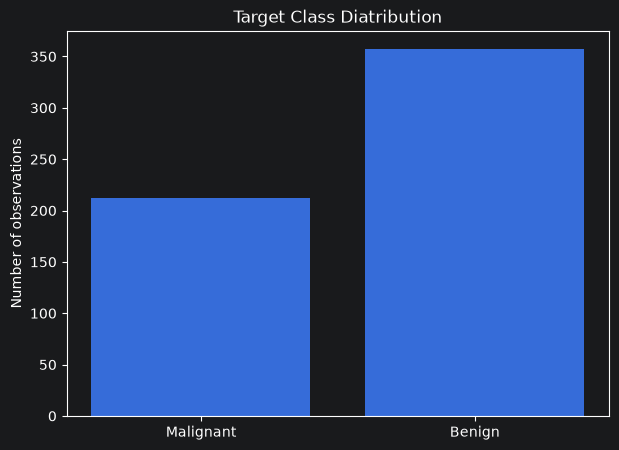

In [21]:
counts=y.value_counts().sort_index()
plt.figure(figsize=(7,5))
plt.bar(["Malignant"
        ,"Benign"],
counts.values,

)
plt.ylabel("Number of observations")
plt.title("Target Class Diatribution")
plt.show()

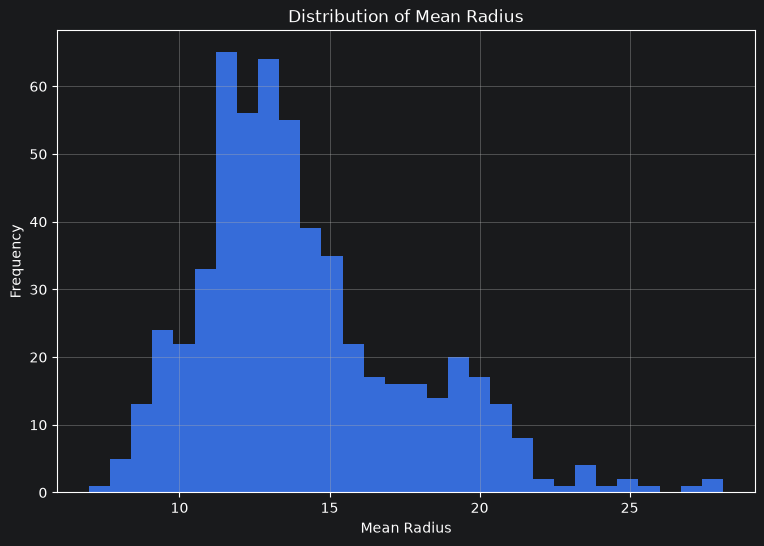

In [22]:
plt.figure(figsize=(9, 6))

plt.hist(
    X["mean radius"],
    bins=30
)

plt.xlabel("Mean Radius")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Mean Radius"
)

plt.grid()

plt.show()

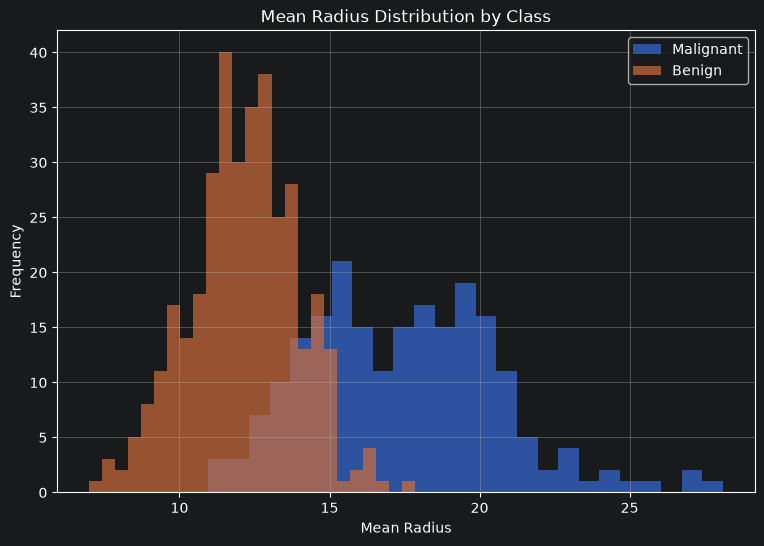

In [24]:
plt.figure(figsize=(9, 6))

plt.hist(
    X.loc[y == 0, "mean radius"],
    bins=25,
    alpha=0.7,
    label="Malignant"
)

plt.hist(
    X.loc[y == 1, "mean radius"],
    bins=25,
    alpha=0.7,
    label="Benign"
)

plt.xlabel("Mean Radius")
plt.ylabel("Frequency")

plt.title(
    "Mean Radius Distribution by Class"
)

plt.legend()
plt.grid()

plt.show()

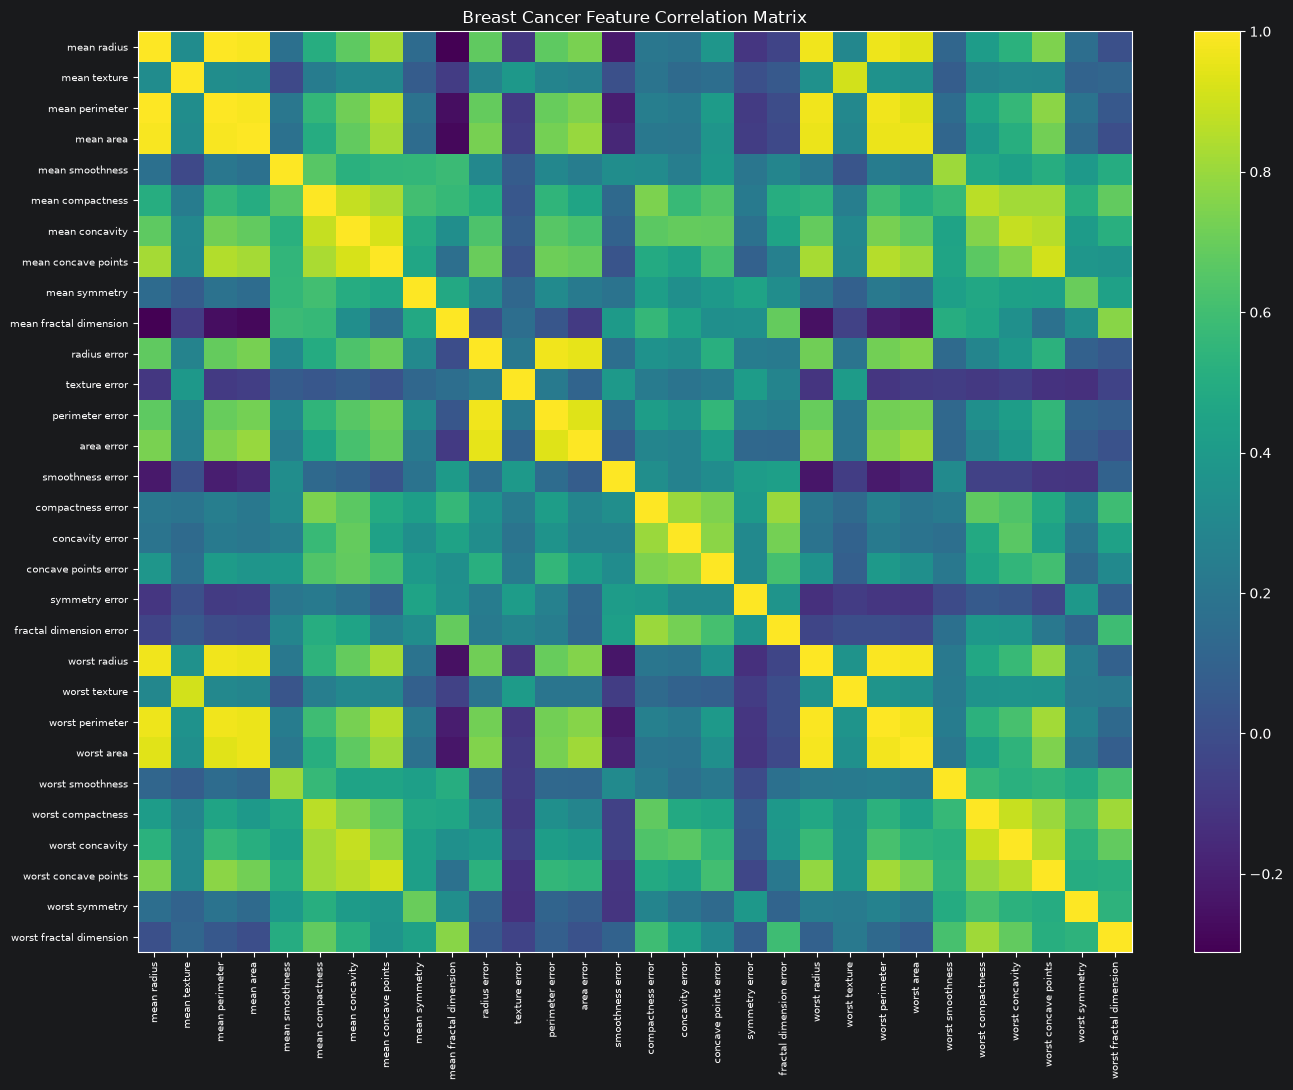

In [29]:
correlation = X.corr()

plt.figure(figsize=(14, 11))

plt.imshow(
    correlation,
    aspect="auto",


)

plt.colorbar()

plt.xticks(
    range(len(X.columns)),
    X.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(X.columns)),
    X.columns,
    fontsize=7
)

plt.title(
    "Breast Cancer Feature Correlation Matrix"
)

plt.tight_layout()

plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (455, 30)
Testing : (114, 30)


In [32]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier(
    n_estimators=500,
    learning_rate=0.3,
    max_depth=3,
min_child_weight=2,
subsample=0.8,
colsample_bytree=0.8,
reg_alpha=0.1,
reg_lambda=1.0,
objective="binary:logistic",
eval_metric="logloss",
early_stopping_rounds=50,
random_state=42




)

In [34]:
xgb_model.fit(
    X_train,y_train,
    eval_set=[(X_test, y_test)],


    verbose=False,



)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [36]:
y_pred=xgb_model.predict(X_test)
y_prob=xgb_model.predict_proba(X_test)[:,1]


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
ROC-AUC  : 0.9937


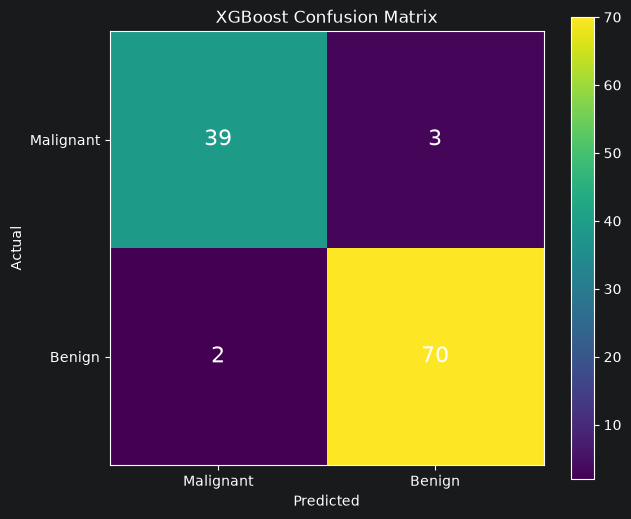

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.yticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16
        )

plt.show()

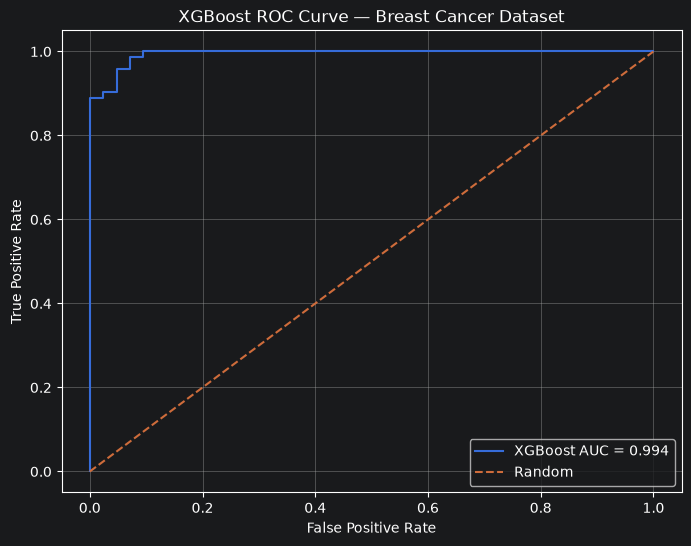

In [40]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "XGBoost ROC Curve — Breast Cancer Dataset"
)

plt.legend()
plt.grid()

plt.show()

In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
20,worst radius,0.253228
22,worst perimeter,0.212089
7,mean concave points,0.154863
27,worst concave points,0.099559
26,worst concavity,0.087572
23,worst area,0.044490
3,mean area,0.016885
1,mean texture,0.016277
24,worst smoothness,0.014329
4,mean smoothness,0.012560


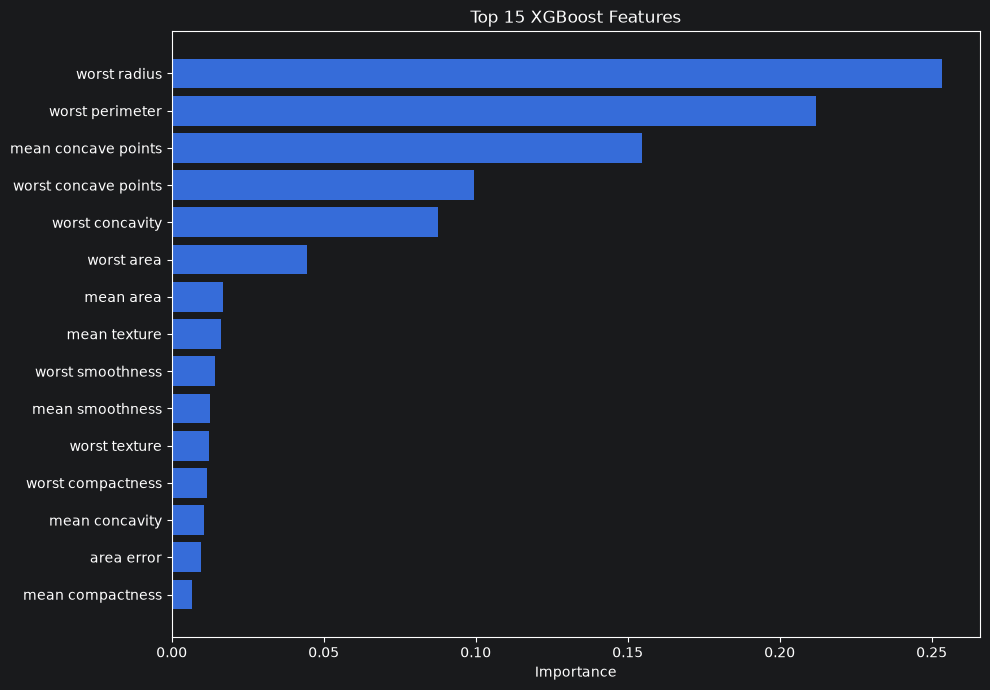

In [42]:
top_features = importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")

plt.title(
    "Top 15 XGBoost Features"
)

plt.tight_layout()

plt.show()